In [ ]:
# Day 4

In [ ]:
# importing nessary lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
data = pd.read_csv('/content/predict_energy_consumption.xls')
data.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013257,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [ ]:
data.columns

Index(['temperature', 'humidity', 'wind_speed', 'solar_irradiance',
       'energy_consumption'],
      dtype='object')

In [ ]:
# feature and target selction
X = data[['temperature','humidity','wind_speed','solar_irradiance']]
y = data['energy_consumption']

In [ ]:
# split the dataset
Xtr,Xte,ytr,yte = train_test_split(X,y,train_size=0.2,random_state=42)

In [ ]:
# standarsize the data
ss = StandardScaler()
Xtr = ss.fit_transform(Xtr)
Xte = ss.transform(Xte)

In [ ]:
# create a neural network
model = Sequential([
    Dense(64,activation='relu',input_shape=(Xtr.shape[1],)),
    Dense(32,activation='relu'),
    Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the model
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
# train the model
history = model.fit(Xtr,ytr,epochs=30,batch_size=32,
                    validation_split=0.2,verbose=2)

Epoch 1/30
5/5 - 4s - 790ms/step - loss: 85518.1719 - mae: 260.0333 - val_loss: 86849.7891 - val_mae: 271.6160
Epoch 2/30
5/5 - 0s - 15ms/step - loss: 85386.4609 - mae: 259.7762 - val_loss: 86714.2656 - val_mae: 271.3669
Epoch 3/30
5/5 - 0s - 17ms/step - loss: 85250.8828 - mae: 259.5161 - val_loss: 86576.5156 - val_mae: 271.1122
Epoch 4/30
5/5 - 0s - 15ms/step - loss: 85117.1719 - mae: 259.2479 - val_loss: 86433.6875 - val_mae: 270.8470
Epoch 5/30
5/5 - 0s - 16ms/step - loss: 84969.5625 - mae: 258.9605 - val_loss: 86281.3047 - val_mae: 270.5637
Epoch 6/30
5/5 - 0s - 15ms/step - loss: 84813.9766 - mae: 258.6571 - val_loss: 86114.8672 - val_mae: 270.2542
Epoch 7/30
5/5 - 0s - 15ms/step - loss: 84644.0234 - mae: 258.3257 - val_loss: 85930.9531 - val_mae: 269.9120
Epoch 8/30
5/5 - 0s - 15ms/step - loss: 84454.7109 - mae: 257.9640 - val_loss: 85727.4844 - val_mae: 269.5327
Epoch 9/30
5/5 - 0s - 15ms/step - loss: 84253.5938 - mae: 257.5541 - val_loss: 85497.7422 - val_mae: 269.1046
Epoch 10/

In [ ]:
test_loss,test_mae = model.evaluate(Xte,yte,verbose=1)
print(f'test mean absolute error is {test_mae:.2f}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 74099.5781 - mae: 240.4417
test mean absolute error is 238.47


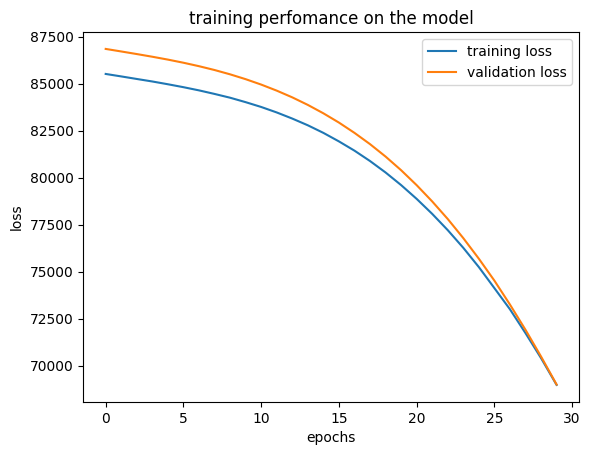

In [ ]:
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('training perfomance on the model')
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(Xte)
predictions

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[29.58152 ],
       [38.690365],
       [29.426718],
       [19.051376],
       [55.718063],
       [51.836132],
       [52.273438],
       [46.90739 ],
       [34.70635 ],
       [32.186604],
       [32.25352 ],
       [40.612076],
       [31.981987],
       [22.430725],
       [42.237274],
       [37.9175  ],
       [35.45582 ],
       [37.34615 ],
       [34.34732 ],
       [40.662174],
       [36.96365 ],
       [35.33891 ],
       [40.270626],
       [28.940203],
       [33.837883],
       [32.08615 ],
       [30.30787 ],
       [39.31707 ],
       [38.969936],
       [41.346893],
       [30.220575],
       [46.31059 ],
       [50.551136],
       [40.37466 ],
       [31.794357],
       [38.87706 ],
       [25.695263],
       [29.967283],
       [50.411602],
       [26.64238 ],
       [30.49858 ],
       [33.512016],
       [30.549072],
       [43.602985],
       [29.540117],
       [29.525133],
       [31.377932],
       [40.246346],
       [36.93521 ],
       [44.668262],


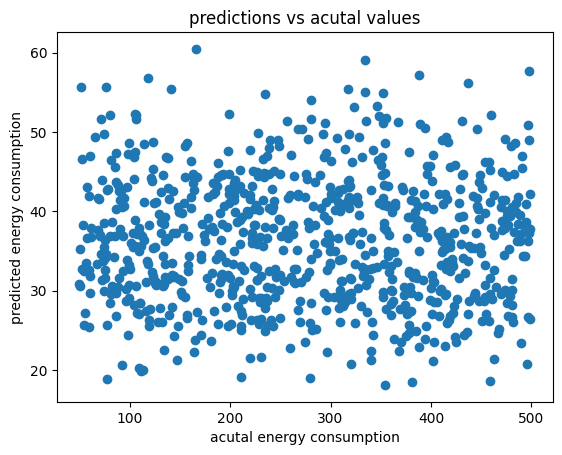

In [ ]:
plt.scatter(yte,predictions)
plt.xlabel('acutal energy consumption')
plt.ylabel('predicted energy consumption')
plt.title('predictions vs acutal values')
plt.show()